# 堆积柱状图

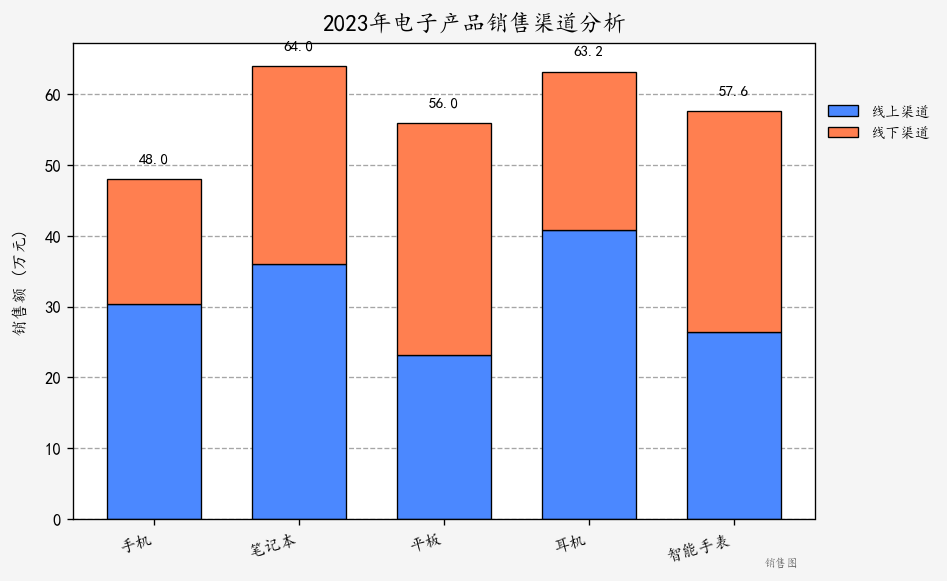

In [7]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# ---------- 自定义字体配置 ----------
# 指定中文字体路径
chinese_font_path = '../simkai.ttf'  # Windows字体示例

# 加载中文字体属性配置
try:
    custom_font = fm.FontProperties(fname=chinese_font_path)
    plt.rcParams['font.family'] = custom_font.get_name()
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示异常
except:
    print("警告：自定义字体加载失败，使用默认字体")

# ---------- 生成模拟数据 ----------
product_categories = ['手机', '笔记本', '平板', '耳机', '智能手表']
# 线上销售额（单位：万元）
online_sales = np.array([38, 45, 29, 51, 33]) * 0.8  # 添加随机波动
# 线下销售额（单位：万元）
offline_sales = np.array([22, 35, 41, 28, 39]) * 0.8
total_sales = online_sales + offline_sales  # 计算总销售额

# ---------- 可视化参数配置 ----------
plot_colors = {
    'online': '#4B88FF',   # 科技蓝
    'offline': '#FF7F50'   # 珊瑚橙
}
bar_width = 0.65  # 柱状图宽度
y_label = '销售额 (万元)'

# ---------- 创建画布和坐标系 ----------
fig, main_ax = plt.subplots(
    figsize=(8, 5),         # 调整画布尺寸
    dpi=120,                # 显示分辨率
    facecolor='#F5F5F5'     # 浅灰色背景
)
fig.suptitle('2023年电子产品销售渠道分析', y=0.95, fontsize=14)

# ---------- 绘制堆叠柱状图 ----------
# 先绘制底层（线上销售）
main_ax.bar(
    product_categories, 
    online_sales, 
    bar_width,
    label='线上渠道',
    color=plot_colors['online'],
    edgecolor='black',
    linewidth=0.8
)

# 再叠加绘制上层（线下销售）
main_ax.bar(
    product_categories, 
    offline_sales, 
    bar_width,
    bottom=online_sales,  # 设置堆叠基准
    label='线下渠道',
    color=plot_colors['offline'],
    edgecolor='black',
    linewidth=0.8
)

# ---------- 添加数据标签 ----------
for idx, total in enumerate(total_sales):
    main_ax.text(
        idx, 
        total + 2,  # 标签位置微调
        f'{total:.1f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# ---------- 坐标系装饰 ----------
main_ax.set_ylabel(y_label, labelpad=10)
main_ax.grid(
    axis='y', 
    linestyle='--', 
    alpha=0.7, 
    color='gray'
)
main_ax.set_axisbelow(True)  # 网格线置于底层

# 旋转X轴标签
plt.setp(
    main_ax.get_xticklabels(), 
    rotation=15, 
    ha='right'
)

# ---------- 图例配置 ----------
main_ax.legend(
    loc='upper left', 
    bbox_to_anchor=(1, 0.9),  # 右侧显示
    frameon=False,
    prop={'size': 9}
)

# ---------- 添加文本信息 ----------
fig.text(
    0.82, 
    0.03, 
    '销售图',
    fontsize=7,
    color='#666666',
    ha='center',
    va='center',
    transform=fig.transFigure
)

# ---------- 保存和显示 ----------
plt.tight_layout()
plt.savefig(
    'sales_channel_analysis.png',
    dpi=600,                   # 输出分辨率
    bbox_inches='tight',       # 自动裁剪白边
    facecolor=fig.get_facecolor()  # 保持背景色一致
)
plt.show()


# 使用灰色系

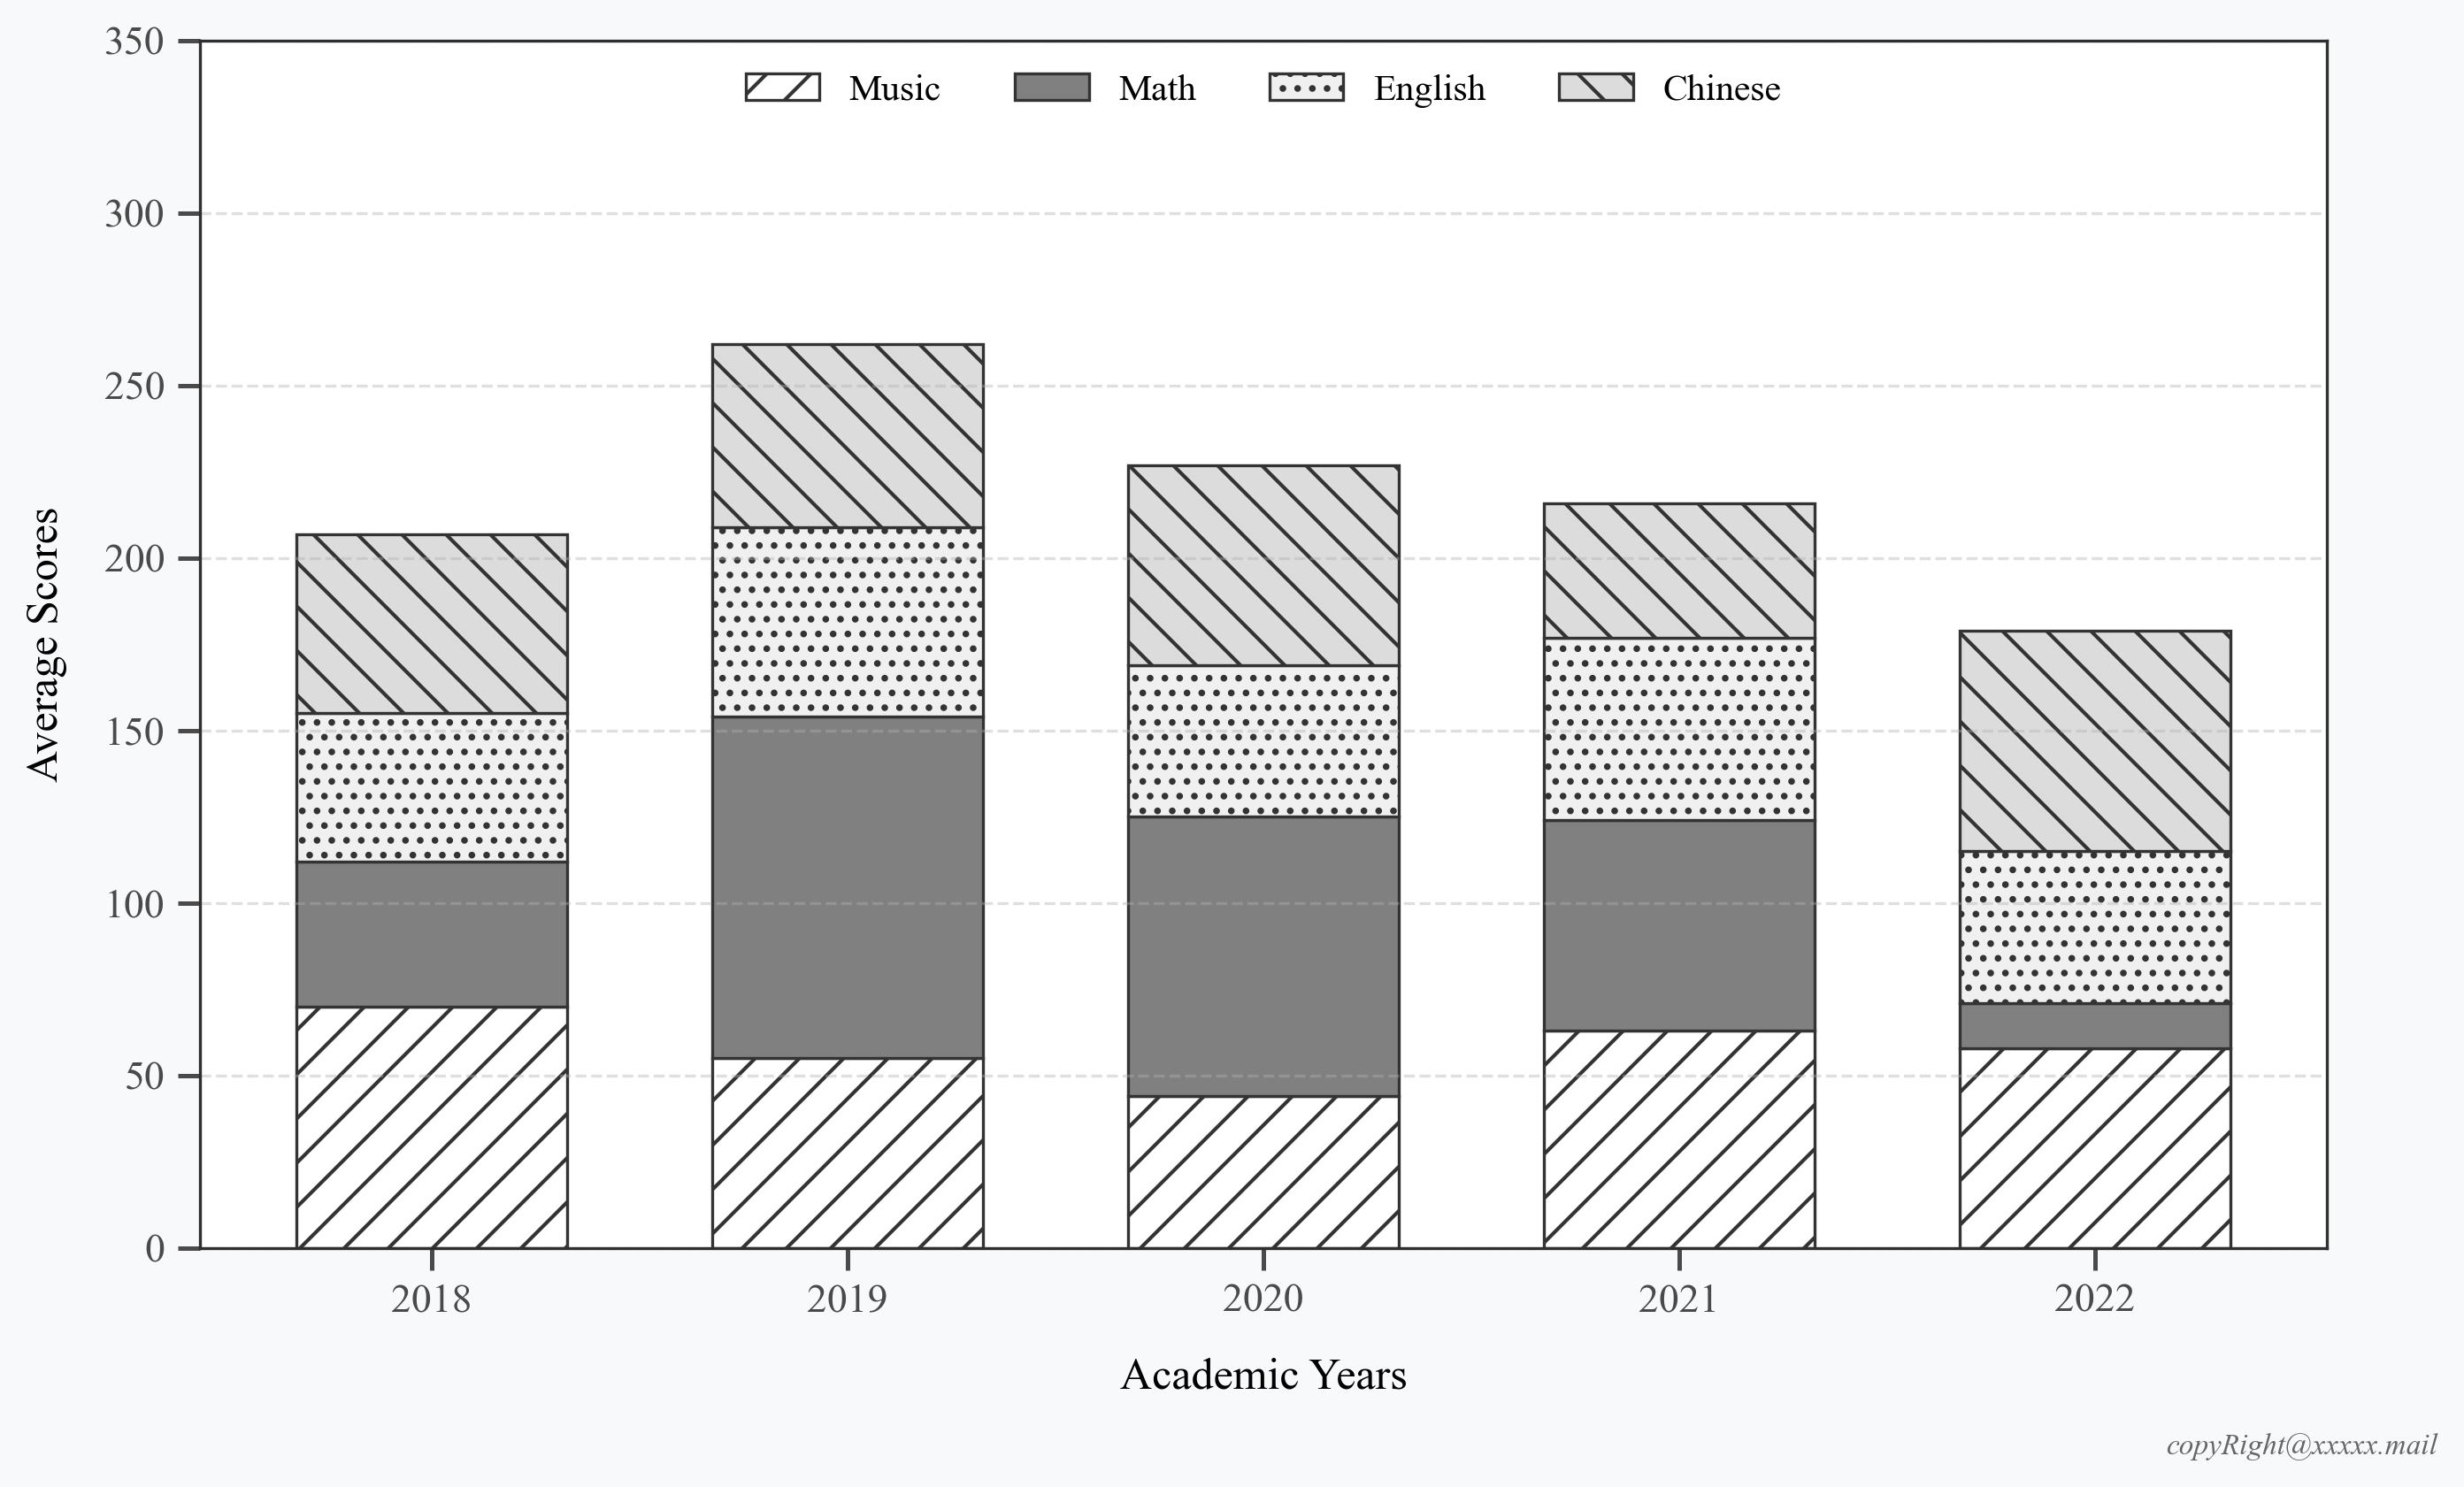

In [22]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- 数据生成模块 ----------
# 生成模拟数据
def generate_mock_dataset():
    years = ['2018', '2019', '2020', '2021', '2022']
    subjects = ['Music', 'Math', 'English', 'Chinese']
    # 创建正态分布数据（均值60，标准差15）
    np.random.seed(2023)
    base_scores = np.abs(np.random.normal(60, 15, (4,5))).astype(int)
    return pd.DataFrame(
        base_scores,
        index=subjects,
        columns=years
    )

# ---------- 样式配置模块 ----------
def configure_plot_style():
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['axes.edgecolor'] = '#2F2F2F'  # 深灰色坐标轴
    
    return {
        'hatch_styles': ['//', None, '...', '\\\\'],  # 填充图案
        'colors': ['#FFFFFF', '#808080', '#F0F0F0', '#DCDCDC'],  # 渐变色系
        'edge_colors': ['#333333']*4,  # 统一边框颜色
        'line_widths': [0.8]*4  # 边框线宽
    }

# ---------- 可视化主函数 ----------
def create_stacked_barplot():
    # 初始化画布
    fig, ax = plt.subplots(
        figsize=(10, 6),
        dpi=300,
        facecolor='#F8F9FA'
    )
    
    # 获取模拟数据
    mock_data = generate_mock_dataset()
    time_labels = mock_data.columns.tolist()
    subject_layers = mock_data.values  # 形状应为 (4,5)
    
    # 获取样式配置
    style_config = configure_plot_style()
    
    # 初始化累积值数组为1维
    cumulative_values = np.zeros(len(time_labels))  # 形状变为 (5,)
    
    for idx, (scores, hatch, color, ec, lw) in enumerate(zip(
        subject_layers,  # 遍历4个学科
        style_config['hatch_styles'],
        style_config['colors'],
        style_config['edge_colors'],
        style_config['line_widths']
    )):
        # 直接使用累积值数组
        ax.bar(
            time_labels, 
            scores,
            bottom=cumulative_values,  # 使用当前累积高度
            width=0.65,
            label=mock_data.index[idx],
            color=color,
            hatch=hatch,
            ec=ec,
            lw=lw
        )
        # 更新累积值
        cumulative_values += scores  # 自动广播到每个时间点
    
    # ---------- 图形装饰模块 ----------
    # 坐标轴设置
    ax.set_ylim(0, 350)
    ax.set_ylabel('Average Scores', fontsize=12, labelpad=10)
    ax.set_xlabel('Academic Years', fontsize=12, labelpad=10)
    
    # 刻度线定制
    ax.tick_params(
        axis='both',
        direction='out',
        length=6,
        width=1.2,
        colors='#4A4A4A',  # 深灰色刻度
        labelsize=11
    )
    
    # 网格线增强
    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.4,
        color='#B0B0B0'
    )
    
    # 图例优化
    ax.legend(
        ncol=4,
        frameon=False,
        loc='upper center',
        bbox_to_anchor=(0.5, 1),  # 右侧外部定位
        fontsize=10
    )
    
    # 添加统计标识
    # ax.text(
    #     0.05, 0.95,
    #     'Experimental Group',
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     weight='bold',
    #     alpha=0.3  # 半透明水印效果
    # )
    
    # 版权信息
    ax.text(
        0.95, 0.03,
        'copyRight@xxxxx.mail',
        transform=fig.transFigure,
        ha='right',
        va='bottom',
        fontsize=8,
        color='#666666',
        style='italic'
    )
    
    # ---------- 输出设置 ----------
    plt.tight_layout(pad=3)
    plt.savefig(
        'academic_performance1.png',
        dpi=1200,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()  # 保持背景一致性
    )
    plt.show()
    # plt.close()

# 执行主函数
if __name__ == "__main__":
    create_stacked_barplot()

# 调整颜色

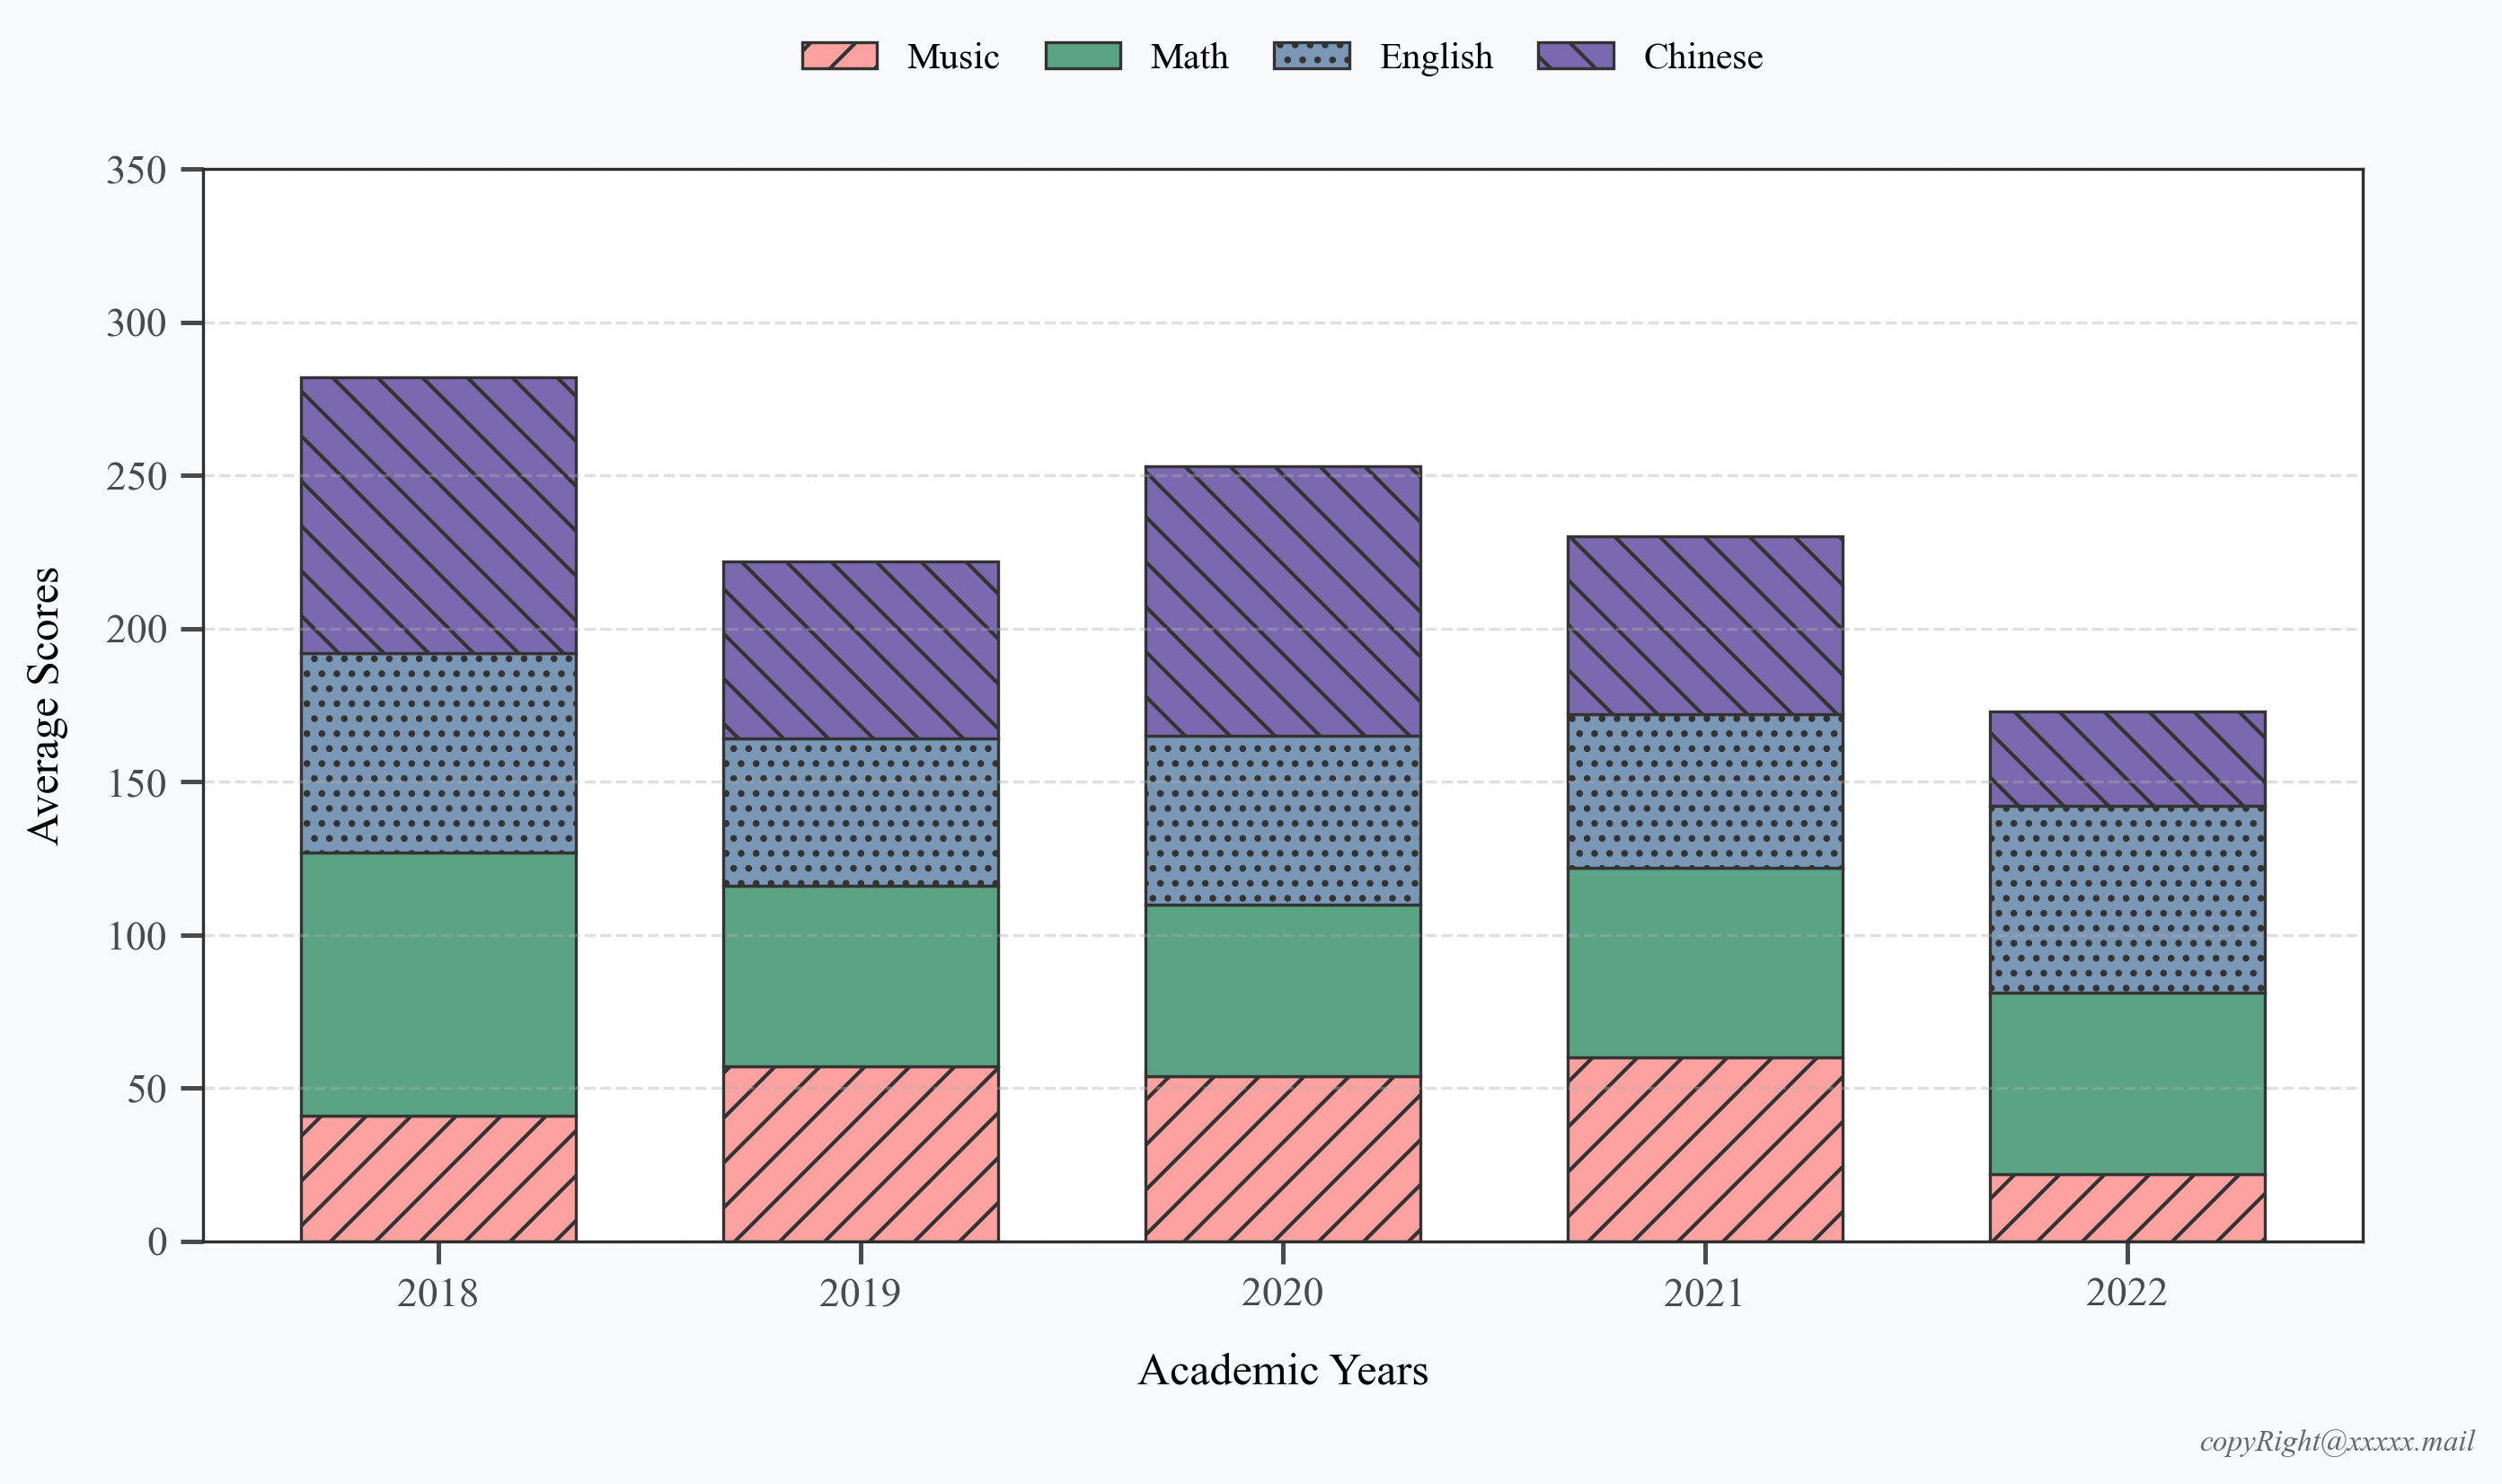

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------- 数据生成模块 ----------
def generate_mock_dataset():
    years = ['2018', '2019', '2020', '2021', '2022']
    subjects = ['Music', 'Math', 'English', 'Chinese']
    
    # 为不同学科设置不同的分布参数
    np.random.seed(2023)
    # 各学科参数配置（均值，标准差）
    subject_params = {
        'Music':    (50, 12),
        'Math':     (70, 8),
        'English':  (65, 10),
        'Chinese':  (60, 15)
    }
    
    # 生成差异化数据
    data = []
    for subj in subjects:
        mu, sigma = subject_params[subj]
        # 添加年度波动因子
        annual_fluctuation = np.random.uniform(0.8, 1.2, len(years))
        scores = np.abs(np.random.normal(mu, sigma, len(years))) * annual_fluctuation
        data.append(scores.astype(int))
    
    return pd.DataFrame(
        np.vstack(data),
        index=subjects,
        columns=years
    )

# ---------- 样式配置模块 ----------
def configure_plot_style():
    plt.rcParams['font.family'] = 'Times New Roman'
    plt.rcParams['axes.edgecolor'] = '#2F2F2F'  # 深灰色坐标轴
    
    return {
        'hatch_styles': ['//', None, '...', '\\\\'],  # 填充图案
        'colors': ['#FDA1A1', '#5AA484', '#7A97B6', '#7969AF'],  # 渐变色系
        'edge_colors': ['#333333']*4,  # 统一边框颜色
        'line_widths': [0.8]*4  # 边框线宽
    }

# ---------- 可视化主函数 ----------
def create_stacked_barplot():
    # 初始化画布
    fig, ax = plt.subplots(
        figsize=(10, 6),
        dpi=300,
        facecolor='#F8F9FA'
    )
    
    # 获取模拟数据
    mock_data = generate_mock_dataset()
    time_labels = mock_data.columns.tolist()
    subject_layers = mock_data.values  # 形状应为 (4,5)
    
    # 获取样式配置
    style_config = configure_plot_style()
    
    # 初始化累积值数组为1维
    cumulative_values = np.zeros(len(time_labels))  # 形状变为 (5,)
    # 坐标轴设置
    ax.set_ylim(0, 350)  # 调整Y轴范围适应新数据
    # 图例位置调整（中间靠上）
    
    for idx, (scores, hatch, color, ec, lw) in enumerate(zip(
        subject_layers,  # 遍历4个学科
        style_config['hatch_styles'],
        style_config['colors'],
        style_config['edge_colors'],
        style_config['line_widths']
    )):
        # 直接使用累积值数组
        ax.bar(
            time_labels, 
            scores,
            bottom=cumulative_values,  # 使用当前累积高度
            width=0.65,
            label=mock_data.index[idx],
            color=color,
            hatch=hatch,
            ec=ec,
            lw=lw
        )
        # 更新累积值
        cumulative_values += scores  # 自动广播到每个时间点
    
    # ---------- 图形装饰模块 ----------
    # 坐标轴设置
    ax.set_ylim(0, 350)
    ax.set_ylabel('Average Scores', fontsize=12, labelpad=10)
    ax.set_xlabel('Academic Years', fontsize=12, labelpad=10)
    
    # 刻度线定制
    ax.tick_params(
        axis='both',
        direction='out',
        length=6,
        width=1.2,
        colors='#4A4A4A',  # 深灰色刻度
        labelsize=11
    )
    
    # 网格线增强
    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.4,
        color='#B0B0B0'
    )
    
    # 图例优化
    ax.legend(
        ncol=4,  # 水平排列
        frameon=False,
        loc='upper center',  # 定位基准点
        bbox_to_anchor=(0.5, 1.15),  # 中间上方偏移
        fontsize=10,
        columnspacing=1.2  # 增加列间距
    )
    # 添加统计标识
    # ax.text(
    #     0.05, 0.95,
    #     'Experimental Group',
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     weight='bold',
    #     alpha=0.3  # 半透明水印效果
    # )
    
    # 版权信息
    ax.text(
        0.95, 0.03,
        'copyRight@xxxxx.mail',
        transform=fig.transFigure,
        ha='right',
        va='bottom',
        fontsize=8,
        color='#666666',
        style='italic'
    )
    
    # ---------- 输出设置 ----------
    plt.tight_layout(pad=3)
    plt.savefig(
        'academic_performance2.png',
        dpi=1200,
        bbox_inches='tight',
        facecolor=fig.get_facecolor()  # 保持背景一致性
    )
    plt.show()
    # plt.close()

# 执行主函数
if __name__ == "__main__":
    create_stacked_barplot()